# ЛР 2.2: Модели классификации

## Теоретическая часть

In [192]:
from sklearn.metrics import r2_score
from sklearn.datasets import load_iris
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler


data = pd.read_csv("https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML2.2%20real%20classification/data/diabetes.csv")
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [193]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [194]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Выделение целевой переменной

In [195]:
y = data.Outcome
X = data.drop(["Outcome"], axis=1)

y.shape, X.shape

((768,), (768, 8))

### Обучение модели

In [196]:
logistic = LogisticRegression()
logistic.fit(X, y)

C:\Users\Bush\PycharmProjects\PythonProject\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [197]:
print("Coefficients: \n", logistic.coef_[0])

Coefficients: 
 [ 1.17252327e-01  3.35996494e-02 -1.40874265e-02 -1.27054305e-03
 -1.24031071e-03  7.72025497e-02  1.41904111e+00  1.00355397e-02]


In [198]:
_ = [print(f"{k:25}:  {v}") for k, v in zip(X.columns, logistic.coef_[0])] # Самый значимый DiabetesPedigreeFunction - функция подсчета диабета наследственно

Pregnancies              :  0.11725232733764228
Glucose                  :  0.033599649400690226
BloodPressure            :  -0.014087426535155847
SkinThickness            :  -0.0012705430523667492
Insulin                  :  -0.0012403107088514358
BMI                      :  0.07720254971447041
DiabetesPedigreeFunction :  1.419041109988383
Age                      :  0.010035539719124393


In [199]:
print("Свободный коэффициент: \n", logistic.intercept_)

Свободный коэффициент: 
 [-7.70289733]


### Прогнозы модели

In [200]:
y_pred = logistic.predict(X)
print("Реальное | Предсказанное")
_ = [print(f"{a:4}     | {b:7}") for a, b in list(zip(y, y_pred))[:10]]

Реальное | Предсказанное
   1     |       1
   0     |       0
   1     |       1
   0     |       0
   1     |       1
   0     |       0
   1     |       0
   0     |       1
   1     |       1
   1     |       0


In [201]:
metrics.confusion_matrix(y, y_pred) # Значения матрицы визуализации

array([[447,  53],
       [114, 154]])

### Визуализация предсказаний

<Axes: >

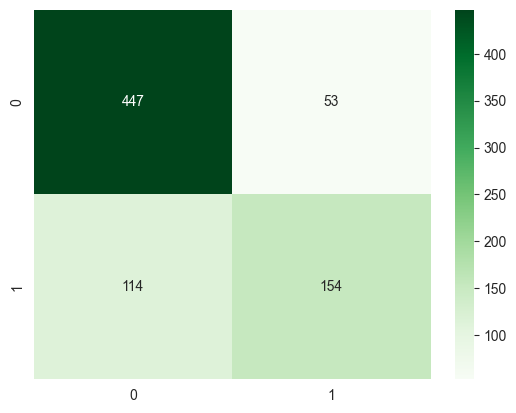

In [202]:
sns.heatmap(metrics.confusion_matrix(y, y_pred), annot=True, fmt='d', cmap='Greens') # Оси y = true; x = predicted
# TP - FP
# TN - FN

In [203]:
print("R2: ", logistic.score(X, y))

R2:  0.7825520833333334


### Улучшение модели полиномом

In [204]:
poly = PolynomialFeatures(2) # 2-ой степени
poly = poly.fit_transform(X)
poly

array([[1.00000e+00, 6.00000e+00, 1.48000e+02, ..., 3.93129e-01,
        3.13500e+01, 2.50000e+03],
       [1.00000e+00, 1.00000e+00, 8.50000e+01, ..., 1.23201e-01,
        1.08810e+01, 9.61000e+02],
       [1.00000e+00, 8.00000e+00, 1.83000e+02, ..., 4.51584e-01,
        2.15040e+01, 1.02400e+03],
       ...,
       [1.00000e+00, 5.00000e+00, 1.21000e+02, ..., 6.00250e-02,
        7.35000e+00, 9.00000e+02],
       [1.00000e+00, 1.00000e+00, 1.26000e+02, ..., 1.21801e-01,
        1.64030e+01, 2.20900e+03],
       [1.00000e+00, 1.00000e+00, 9.30000e+01, ..., 9.92250e-02,
        7.24500e+00, 5.29000e+02]], shape=(768, 45))

In [205]:
polynomial = LogisticRegression()
polynomial.fit(poly, y)
y_pred_poly = polynomial.predict(poly)

C:\Users\Bush\PycharmProjects\PythonProject\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


<Axes: >

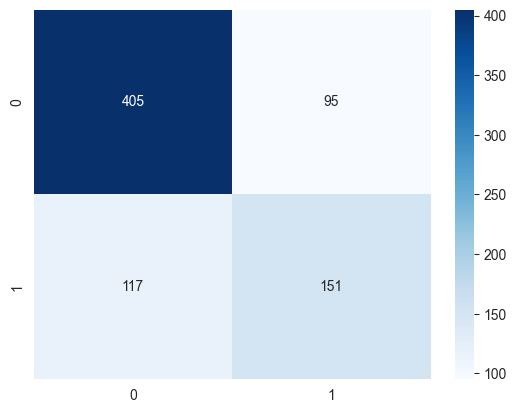

In [206]:
sns.heatmap(metrics.confusion_matrix(y, y_pred_poly), annot=True, fmt='d', cmap='Blues') # Оси y = true; x = predicted
# TP - FP
# TN - FN

In [207]:
print("R2: ", polynomial.score(poly, y))

R2:  0.7239583333333334


# =======================================================================================

# **Самостоятельные задания**

## 1. Изменения аргументов при создании модели

In [208]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

models = [LogisticRegression(max_iter=100, C=1.0, penalty='l2', solver='lbfgs', fit_intercept=True, random_state=42), # C: Обратная величина регуляризации (регуляризация сильнее при меньших C)
          LogisticRegression(max_iter=200, C=0.1, penalty='l1', solver='saga', fit_intercept=True, random_state=42), # penalty: Тип используемой регуляризации ('l1', 'l2', 'elasticnet', 'none') - способ сделать модель более устойчивой и предотвратить переобучение
          LogisticRegression(max_iter=400, C=10, penalty='l1', solver='saga', fit_intercept=False, random_state=42)] # solver: Алгоритм оптимизации для минимизации функции потерь
                                                                                                                    # max_iter: Максимальное число итераций для сходимости
                                                                                                                    # fit_intercept: Добавлять ли свободный член (смещение)

for model in models:
    model.fit(X_train, y_train)

    # Предсказываем на тестовой выборке
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Выводим параметры модели
    print("Коэффициенты модели:\n", model.coef_)
    print()
    print("Свободный член: ", *model.intercept_)
    print()
    print("Число итераций до сходимости: ", *model.n_iter_)
    print()
    print("Классы:\n", model.classes_)

    # Метрики
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    print("\nAccuracy на тестовых данных:", accuracy)
    print("ROC-AUC на тестовых данных:", roc_auc)

    # Детальный отчет
    print("\nОтчет классификации:\n", classification_report(y_test, y_pred))
    print()
    print("<==========================================================>")
    print()

Коэффициенты модели:
 [[ 0.05654346  0.03558451 -0.01087779 -0.00179054 -0.00098901  0.10761164
   0.52393691  0.03582557]]

Свободный член:  -9.390741713429367

Число итераций до сходимости:  100

Классы:
 [0 1]

Accuracy на тестовых данных: 0.7402597402597403
ROC-AUC на тестовых данных: 0.8002483443708608

Отчет классификации:
               precision    recall  f1-score   support

           0       0.80      0.80      0.80       151
           1       0.62      0.62      0.62        80

    accuracy                           0.74       231
   macro avg       0.71      0.71      0.71       231
weighted avg       0.74      0.74      0.74       231


<==========================================================>

Коэффициенты модели:
 [[ 0.02822675  0.01204028 -0.03147042 -0.00392603  0.00076922  0.
   0.          0.00586489]]

Свободный член:  -0.011601732999063627

Число итераций до сходимости:  200

Классы:
 [0 1]

Accuracy на тестовых данных: 0.6796536796536796
ROC-AUC на тестовых д

C:\Users\Bush\PycharmProjects\PythonProject\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Bush\PycharmProjects\PythonProject\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\Bush\PycharmProjects\PythonProject\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converg

## 2. Другие модели классификации

Всего 231 образцов в тестовых данных

===================================================================================>

Логистическая регрессия
Матрица ошибок:



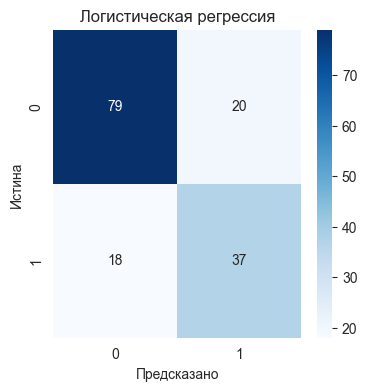

Точность: 0.7532467532467533

===================================================================================>


SVM (без ядра)
Матрица ошибок:



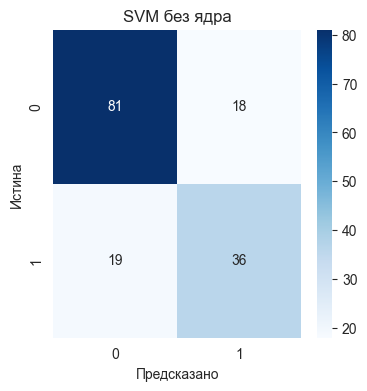

Точность: 0.7597402597402597

===================================================================================>


LinearSVC
Матрица ошибок:



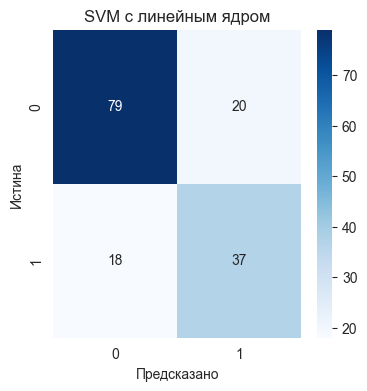

Точность: 0.7532467532467533

===================================================================================>


KNeighborsClassifier
Матрица ошибок:



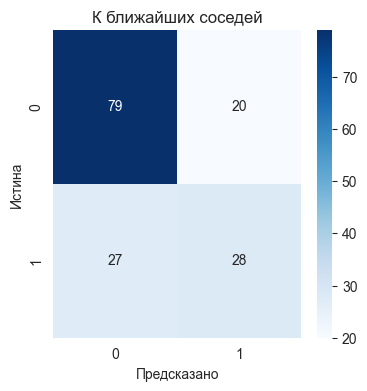

Точность: 0.6948051948051948

===================================================================================>


MLPClassifier
Матрица ошибок:



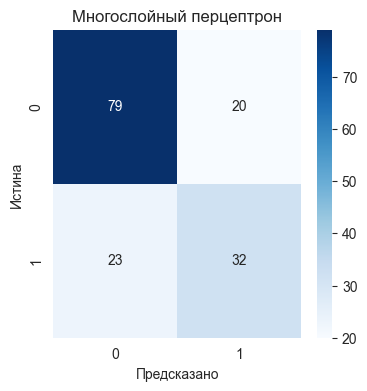

Точность: 0.7207792207792207

===================================================================================>


DecisionTreeClassifier
Матрица ошибок:



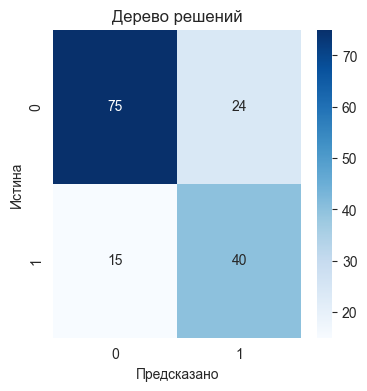

Точность: 0.7467532467532467

===================================================================================>


RandomForestClassifier
Матрица ошибок:



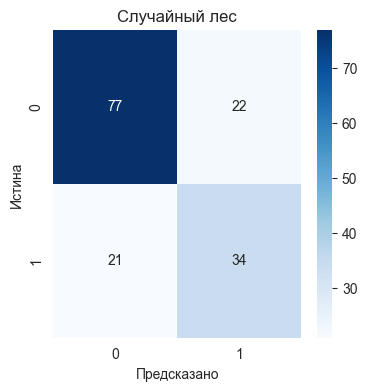

Точность: 0.7207792207792207


In [209]:
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score


def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel('Предсказано')
    plt.ylabel('Истина')
    plt.show()


data_url = "https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML2.2%20real%20classification/data/diabetes.csv"
data = pd.read_csv(data_url)

print("Всего 231 образцов в тестовых данных")
print()
print("===================================================================================>")
print()

# Выделим признаки и целевую переменную
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

# Разделим данные на тренировочную и тестовую выборки, чтобы видеть модель на новых данных
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Масштабируем признаки, т.к. многие методы чувствительны к шкале
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ----------------------------------------------------------------------------|

# 1. Логистическая регрессия
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)
print("Логистическая регрессия")
print("Матрица ошибок:\n")
plot_confusion_matrix(y_test, y_pred_lr, "Логистическая регрессия")
print("Точность:", accuracy_score(y_test, y_pred_lr))

print()
print("===================================================================================>")
print()

# 2. Метод опорных векторов (SVM без ядра)
model_svc = SVC(kernel='linear', max_iter=10000)  # без ядра — с линейным
model_svc.fit(X_train, y_train)
y_pred_svc = model_svc.predict(X_test)
print("\nSVM (без ядра)")
print("Матрица ошибок:\n")
plot_confusion_matrix(y_test, y_pred_svc, "SVM без ядра")
print("Точность:", accuracy_score(y_test, y_pred_svc))

print()
print("===================================================================================>")
print()


# 3. Метод опорных векторов (линейное ядро, явно)
model_linear = LinearSVC(max_iter=10000)
model_linear.fit(X_train, y_train)
y_pred_linear = model_linear.predict(X_test)
print("\nLinearSVC")
print("Матрица ошибок:\n")
plot_confusion_matrix(y_test, y_pred_linear, "SVM с линейным ядром")
print("Точность:", accuracy_score(y_test, y_pred_linear))

print()
print("===================================================================================>")
print()


# 4. Метод ближайших соседей
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print("\nKNeighborsClassifier")
print("Матрица ошибок:\n")
plot_confusion_matrix(y_test, y_pred_knn, "К ближайших соседей")
print("Точность:", accuracy_score(y_test, y_pred_knn))

print()
print("===================================================================================>")
print()


# 5. Многослойный перцептрон (нейросеть)
mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)
print("\nMLPClassifier")
print("Матрица ошибок:\n")
plot_confusion_matrix(y_test, y_pred_mlp, "Многослойный перцептрон")
print("Точность:", accuracy_score(y_test, y_pred_mlp))

print()
print("===================================================================================>")
print()


# 6. Дерево решений
dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train, y_train)
y_pred_dtree = dtree.predict(X_test)
print("\nDecisionTreeClassifier")
print("Матрица ошибок:\n")
plot_confusion_matrix(y_test, y_pred_dtree, "Дерево решений")
print("Точность:", accuracy_score(y_test, y_pred_dtree))

print()
print("===================================================================================>")
print()


# 7. Случайный лес
rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc.fit(X_train, y_train)
y_pred_rfc = rfc.predict(X_test)
print("\nRandomForestClassifier")
print("Матрица ошибок:\n")
plot_confusion_matrix(y_test, y_pred_rfc, "Случайный лес")
print("Точность:", accuracy_score(y_test, y_pred_rfc))

## 3. Функция с автоматическим обучением

Логистическая регрессия: Точность = 0.7532


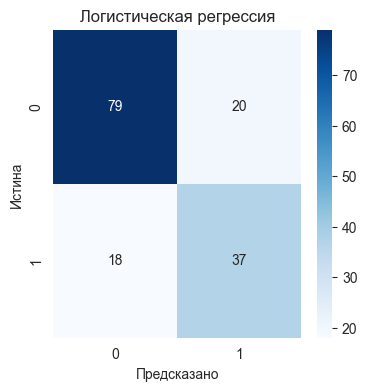

SVM без ядра: Точность = 0.7597


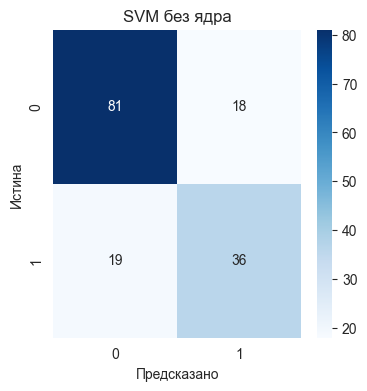

SVM с линейным ядром: Точность = 0.7532


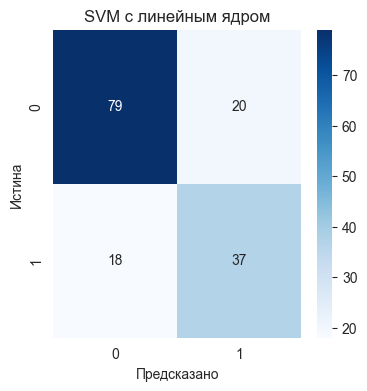

K ближайших соседей: Точность = 0.6948


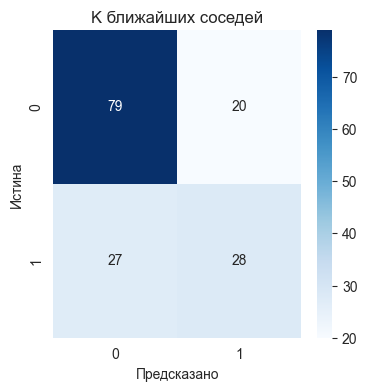

Многослойный перцептрон: Точность = 0.7208


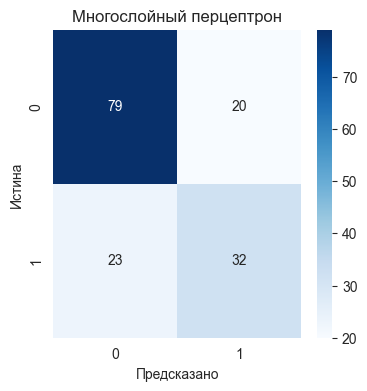

Дерево решений: Точность = 0.7468


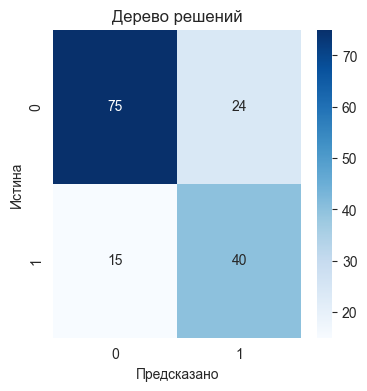

Случайный лес: Точность = 0.7208


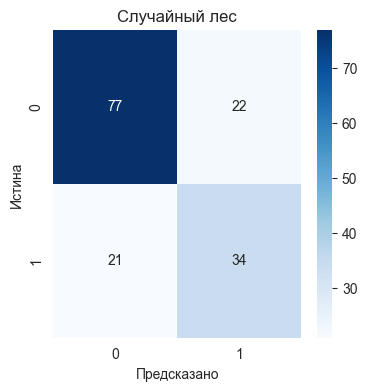

In [210]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel('Предсказано')
    plt.ylabel('Истина')
    plt.show()

# Функция для обучения и оценки набора моделей
def train_and_evaluate_models(X_train, X_test, y_train, y_test):
    # Объявляем список моделей
    models = [
        ("Логистическая регрессия", LogisticRegression(max_iter=1000)),
        ("SVM без ядра", SVC(kernel='linear', max_iter=10000)),
        ("SVM с линейным ядром", LinearSVC(max_iter=10000)),
        ("K ближайших соседей", KNeighborsClassifier(n_neighbors=5)),
        ("Многослойный перцептрон", MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42)),
        ("Дерево решений", DecisionTreeClassifier(random_state=42)),
        ("Случайный лес", RandomForestClassifier(n_estimators=100, random_state=42)),
    ]

    # Проходим по моделям
    for name, model in models:
        # Обучение модели
        model.fit(X_train, y_train)
        # Предсказания
        y_pred = model.predict(X_test)
        # Расчет точности
        acc = accuracy_score(y_test, y_pred)
        print(f"{name}: Точность = {acc:.4f}")
        # Визуализация матрицы ошибок
        plot_confusion_matrix(y_test, y_pred, name)

# Вызов функции
train_and_evaluate_models(X_train, X_test, y_train, y_test)

## 4. Анализ другого датасета с рисом

In [211]:
rice = load_iris()
type(rice)

sklearn.utils._bunch.Bunch

In [212]:
rice.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [213]:
print(type(rice.data), type(rice.target))
print(rice.data.shape, rice.target.shape)


<class 'numpy.ndarray'> <class 'numpy.ndarray'>
(150, 4) (150,)


In [214]:
print(rice.feature_names)
print(rice.target_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']


### Работа с данными

In [215]:
X = rice.data
y = rice.target
target_names = rice.target_names
data = pd.DataFrame(X, columns=rice.feature_names)
data

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [216]:
tar = pd.DataFrame(y, columns=["Rice class"])
tar

,Rice class
0,0
1,0
2,0
3,0
4,0
...,...
145,2
146,2
147,2
148,2


In [217]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


In [218]:
data.describe().round(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


### Создание модели

In [219]:
logistic = LogisticRegression()
logistic.fit(X, y)

C:\Users\Bush\PycharmProjects\PythonProject\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [220]:
print("Коэффициенты: \n", logistic.coef_[0])

Коэффициенты: 
 [-0.4209546   0.96519335 -2.51988104 -1.0843026 ]


In [221]:
_ = [print(f"{k:22}:  {v}") for k, v in zip(data, logistic.coef_[0])]

sepal length (cm)     :  -0.4209545986562019
sepal width (cm)      :  0.9651933517561706
petal length (cm)     :  -2.519881044546461
petal width (cm)      :  -1.0843026033323284


In [222]:
print("Свободные члены: \n", logistic.intercept_)

Свободные члены: 
 [  9.85747913   2.23016359 -12.08764272]


In [223]:
y_pred = logistic.predict(X)

print("Реальное | Предсказанное")
_ = [print(f"{a:4}     | {b:7}") for a, b in list(zip(y, y_pred))]

Реальное | Предсказанное
   0     |       0
   0     |       0
   0     |       0
   0     |       0
   0     |       0
   0     |       0
   0     |       0
   0     |       0
   0     |       0
   0     |       0
   0     |       0
   0     |       0
   0     |       0
   0     |       0
   0     |       0
   0     |       0
   0     |       0
   0     |       0
   0     |       0
   0     |       0
   0     |       0
   0     |       0
   0     |       0
   0     |       0
   0     |       0
   0     |       0
   0     |       0
   0     |       0
   0     |       0
   0     |       0
   0     |       0
   0     |       0
   0     |       0
   0     |       0
   0     |       0
   0     |       0
   0     |       0
   0     |       0
   0     |       0
   0     |       0
   0     |       0
   0     |       0
   0     |       0
   0     |       0
   0     |       0
   0     |       0
   0     |       0
   0     |       0
   0     |       0
   0     |       0
   1     |       1
   1  

### Метрики качества модели и их визуализация

In [224]:
metrics.confusion_matrix(y, y_pred)

array([[50,  0,  0],
       [ 0, 47,  3],
       [ 0,  1, 49]])

<Axes: >

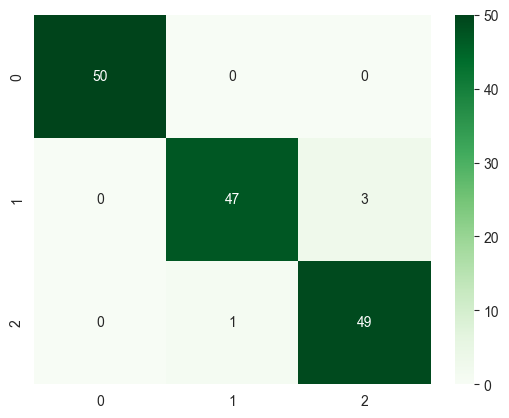

In [225]:
sns.heatmap(metrics.confusion_matrix(y, y_pred), annot=True, fmt='d', cmap='Greens') # Оси y = true; x = predicted
# TP - FP
# TN - FN

In [226]:
print("R2: ", logistic.score(X, y))

R2:  0.9733333333333334


### Улучшим модель полномиальной моделью

In [227]:
poly = PolynomialFeatures(2)
poly = poly.fit_transform(X)
poly

array([[ 1.  ,  5.1 ,  3.5 , ...,  1.96,  0.28,  0.04],
       [ 1.  ,  4.9 ,  3.  , ...,  1.96,  0.28,  0.04],
       [ 1.  ,  4.7 ,  3.2 , ...,  1.69,  0.26,  0.04],
       ...,
       [ 1.  ,  6.5 ,  3.  , ..., 27.04, 10.4 ,  4.  ],
       [ 1.  ,  6.2 ,  3.4 , ..., 29.16, 12.42,  5.29],
       [ 1.  ,  5.9 ,  3.  , ..., 26.01,  9.18,  3.24]], shape=(150, 15))

In [228]:
polynomial = LogisticRegression()
polynomial.fit(poly, y)
y_pred_poly = polynomial.predict(poly)

C:\Users\Bush\PycharmProjects\PythonProject\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


<Axes: >

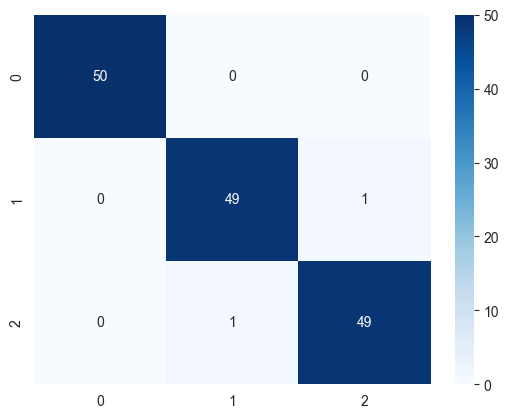

In [229]:
sns.heatmap(metrics.confusion_matrix(y, y_pred_poly), annot=True, fmt='d', cmap='Blues') # Оси y = true; x = predicted
# TP - FP
# TN - FN

In [230]:
print("R2: ", r2_score(y, y_pred_poly))

R2:  0.98
